# Лабораторная работа № 2
## Сверточные нейронные сети
### Набокова Алиса Владиславовна P3320 409211

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from tensorflow import keras
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras import callbacks
import numpy as np


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("misrakahmed/vegetable-image-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'vegetable-image-dataset' dataset.
Path to dataset files: /kaggle/input/vegetable-image-dataset


In [ ]:
print(os.listdir(path))

train_path = path + "/Vegetable Images/train"
validation_path = path + "/Vegetable Images/validation"
test_path = path + "/Vegetable Images/test"

image_categories = os.listdir(path + "/Vegetable Images/train")


['Vegetable Images']


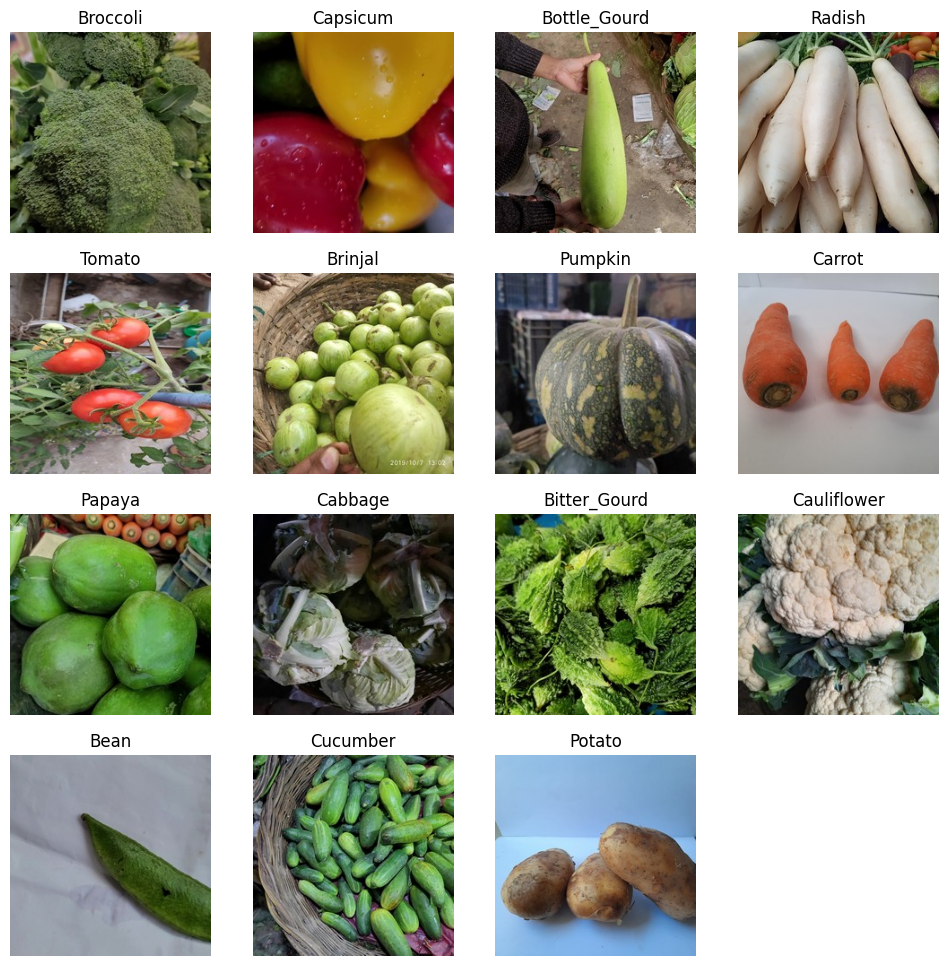

In [ ]:
plt.figure(figsize=(12, 12))

for i, cat in enumerate(image_categories):
    img_path = os.path.join(train_path, cat, os.listdir(os.path.join(train_path, cat))[0])
    img = image.load_img(img_path)
    plt.subplot(4, 4, i+1)
    plt.imshow(image.img_to_array(img)/255.0)
    plt.title(cat)
    plt.axis('off')

plt.show()

In [ ]:

train_gen = ImageDataGenerator(rescale = 1.0/255.0)
train_image_generator = train_gen.flow_from_directory(
                                            train_path,
                                            target_size=(150, 150),
                                            batch_size=32,
                                            class_mode='categorical')

val_gen = ImageDataGenerator(rescale = 1.0/255.0)
val_image_generator = val_gen.flow_from_directory(
                                            validation_path,
                                            target_size=(150, 150),
                                            batch_size=32,
                                            class_mode='categorical')

test_gen = ImageDataGenerator(rescale = 1.0/255.0)
test_image_generator = test_gen.flow_from_directory(
                                            test_path,
                                            target_size=(150, 150),
                                            batch_size=32,
                                            class_mode='categorical')

Found 15000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.


In [ ]:
class_map = dict([(v, k) for k, v in train_image_generator.class_indices.items()])
print(class_map)

{0: 'Bean', 1: 'Bitter_Gourd', 2: 'Bottle_Gourd', 3: 'Brinjal', 4: 'Broccoli', 5: 'Cabbage', 6: 'Capsicum', 7: 'Carrot', 8: 'Cauliflower', 9: 'Cucumber', 10: 'Papaya', 11: 'Potato', 12: 'Pumpkin', 13: 'Radish', 14: 'Tomato'}


In [ ]:
model = Sequential()

model.add(Conv2D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu', input_shape = [150, 150, 3]))
model.add(MaxPooling2D(2))
model.add(Conv2D(filters=128, kernel_size=3, strides=1, padding='same', activation='relu'))
model.add(MaxPooling2D(2))

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(32, activation='relu'))
model.add(Dense(15, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 175232)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    11,214,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,293,135 (43.08 MB)

 Trainable params: 11,293,135 (43.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_image_generator,
                 epochs=10,
                 verbose=1,
                 steps_per_epoch = 15000//32,
                 validation_steps = 3000//32,
                 validation_data=val_image_generator,
                 )

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1475s 3s/step - accuracy: 0.2777 - loss: 2.1988 - val_accuracy: 0.7153 - val_loss: 0.9871
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1474s 3s/step - accuracy: 0.6286 - loss: 1.1207 - val_accuracy: 0.7687 - val_loss: 0.7350
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1492s 3s/step - accuracy: 0.7180 - loss: 0.8436 - val_accuracy: 0.8547 - val_loss: 0.5092
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1484s 3s/step - accuracy: 0.7890 - loss: 0.6162 - val_accuracy: 0.8623 - val_loss: 0.4466
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1568s 3s/step - accuracy: 0.8265 - loss: 0.5228 - val_accuracy: 0.8753 - val_loss: 0.4359
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1525s 3s/step - accuracy: 0.8530 - loss: 0.4160 - val_accuracy: 0.8950 - val_loss: 0.3697
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1532s 3s/step - accuracy: 0.8701 - loss: 0.3771 - val_accuracy: 0.8867 - val_loss: 0.4019
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1510s 3s/step - accuracy: 0.8882 - loss: 0.3266 - 

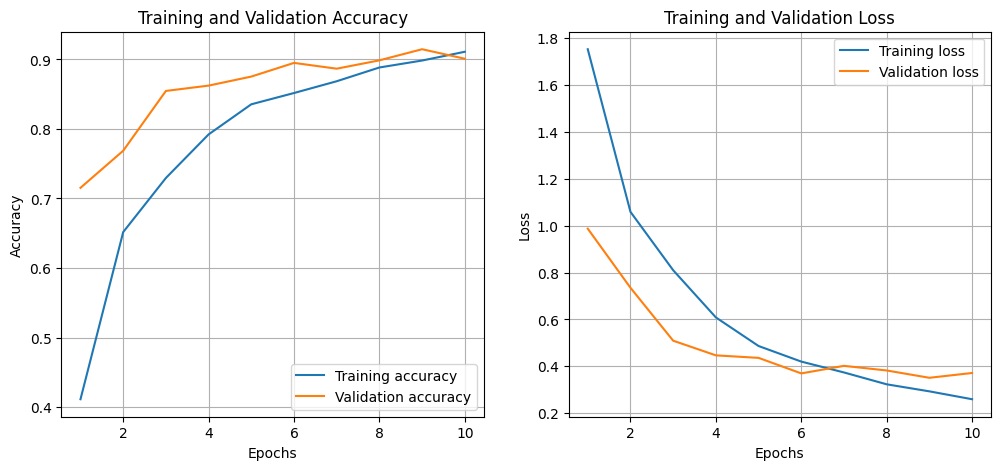

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Training accuracy')
plt.plot(epochs, val_acc, label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, loss,label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()


In [ ]:
model.save('my_model.keras')

In [ ]:
model.evaluate(test_image_generator)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


94/94 ━━━━━━━━━━━━━━━━━━━━ 82s 854ms/step - accuracy: 0.9027 - loss: 0.3287


[0.34392037987709045, 0.9006666541099548]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


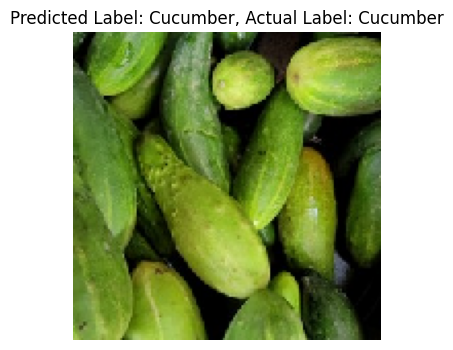

In [ ]:
test_image_path = path + '/Vegetable Images/test/Cucumber/1003.jpg'

def generate_predictions(test_image_path, actual_label):

    test_img = image.load_img(test_image_path, target_size=(150, 150))
    test_img_arr = image.img_to_array(test_img)/255.0
    test_img_input = test_img_arr.reshape((1, test_img_arr.shape[0], test_img_arr.shape[1], test_img_arr.shape[2]))

    predicted_label = np.argmax(model.predict(test_img_input))
    predicted_vegetable = class_map[predicted_label]
    plt.figure(figsize=(4, 4))
    plt.imshow(test_img_arr)
    plt.title("Predicted Label: {}, Actual Label: {}".format(predicted_vegetable, actual_label))
    plt.grid()
    plt.axis('off')
    plt.show()

generate_predictions(test_image_path, actual_label='Cucumber')

In [ ]:
!wget https://www.abri-kos.ru/upload/iblock/7e0/7e0797a7f095a427d8ab60185458ecb7.jpg

--2025-10-22 21:17:28--  https://www.abri-kos.ru/upload/iblock/7e0/7e0797a7f095a427d8ab60185458ecb7.jpg
Resolving www.abri-kos.ru (www.abri-kos.ru)... 185.195.146.138
Connecting to www.abri-kos.ru (www.abri-kos.ru)|185.195.146.138|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 37986 (37K) [image/jpeg]
Saving to: ‘7e0797a7f095a427d8ab60185458ecb7.jpg’

7e0797a7f095a427d8a 100%[===================>]  37.10K  --.-KB/s    in 0s      

2025-10-22 21:17:29 (297 MB/s) - ‘7e0797a7f095a427d8ab60185458ecb7.jpg’ saved [37986/37986]



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


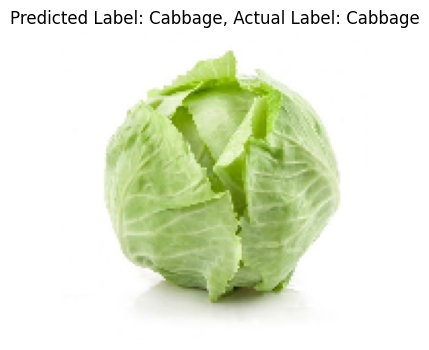

In [ ]:
external_image_path = './7e0797a7f095a427d8ab60185458ecb7.jpg'
generate_predictions(external_image_path, actual_label='Cabbage')